<a href="https://colab.research.google.com/github/adombe/avcad_final_project/blob/main/04_permanent_temporary_crops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
temp = pd.read_csv('temporary_crops_holdings_clean.csv')
perm = pd.read_csv('permanent_crops_holdings_clean.csv')
area = pd.read_csv('agricultural_holdings_area_clean.csv')

# Sort by year
temp = temp.sort_values('year')
perm = perm.sort_values('year')
area = area.sort_values('year')

# Define crop categories for temporary crops
temp_crop_cols = ['Grain cereals', 'Dried pulses for grain', 'Temporary meadows',
                  'Forage crops', 'Potatoes', 'Sugar beet', 'Industrial crops',
                  'Horticultural crops', 'Flowers and ornamental plants', 'Other temporary crops']

# Display first rows to verify data loaded correctly
print("Temporary Crops Data:")
print(temp.head())
print("\nPermanent Crops Data:")
print(perm.head())
print("\nArea Data:")
print(area.head())

Temporary Crops Data:
   year geographic_location  code   Total  Grain cereals  \
3  1989          Continente     1  446915         352158   
2  1999          Continente     1  280214         190446   
1  2009          Continente     1  165265         108524   
0  2019          Continente     1  124902          66584   

   Dried pulses for grain  Temporary meadows  Forage crops  Potatoes  \
3                  222230              40645        285468    312443   
2                   87021              19531        180000    163360   
1                   28882              13293        102983     56969   
0                   15945              14066         65416     34570   

   Sugar beet  Industrial crops  Horticultural crops  \
3        33.0              3638                77052   
2       495.0              3738                48610   
1         NaN              1364                18141   
0         NaN              1147                15874   

   Flowers and ornamental plants  O

Table 3.11 - Temporary Crop Holdings

Table 3.11 — Temporary Crop Holdings by Category (1989–2019)
                Crop Category     1989     1999     2009     2019 Change (%)
        Total Temporary Crops 124902.0 165265.0 280214.0 446915.0     -72.1%
                Grain cereals  66584.0 108524.0 190446.0 352158.0     -81.1%
       Dried pulses for grain  15945.0  28882.0  87021.0 222230.0     -92.8%
            Temporary meadows  14066.0  13293.0  19531.0  40645.0     -65.4%
                 Forage crops  65416.0 102983.0 180000.0 285468.0     -77.1%
                     Potatoes  34570.0  56969.0 163360.0 312443.0     -88.9%
                   Sugar beet      NaN      NaN    495.0     33.0       nan%
             Industrial crops   1147.0   1364.0   3738.0   3638.0     -68.5%
          Horticultural crops  15874.0  18141.0  48610.0  77052.0     -79.4%
Flowers and ornamental plants   1005.0   1056.0   1744.0   1788.0     -43.8%
        Other temporary crops   1718.0   1424.0  20662.0  65133.0     -97.4%


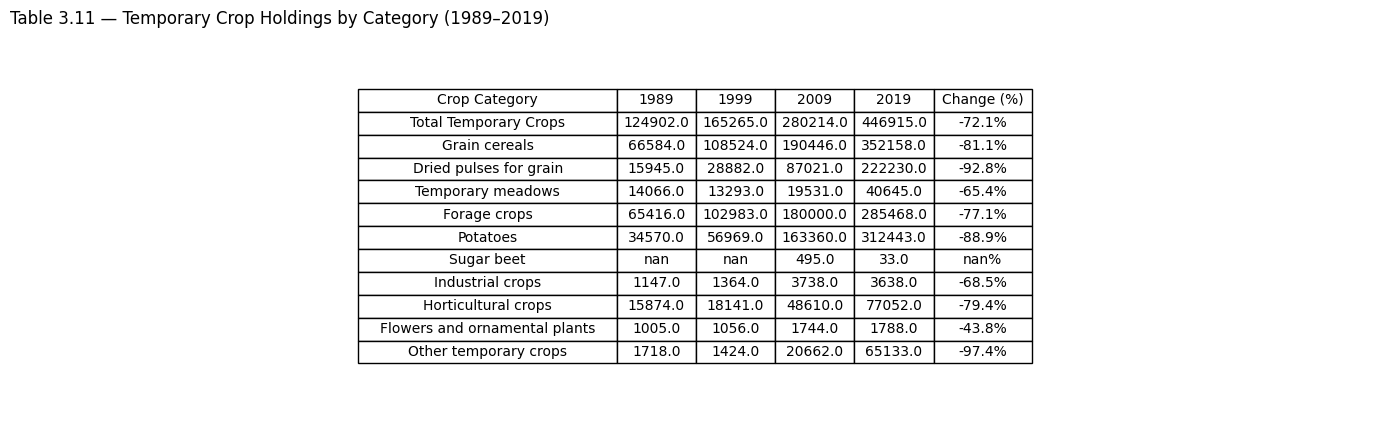

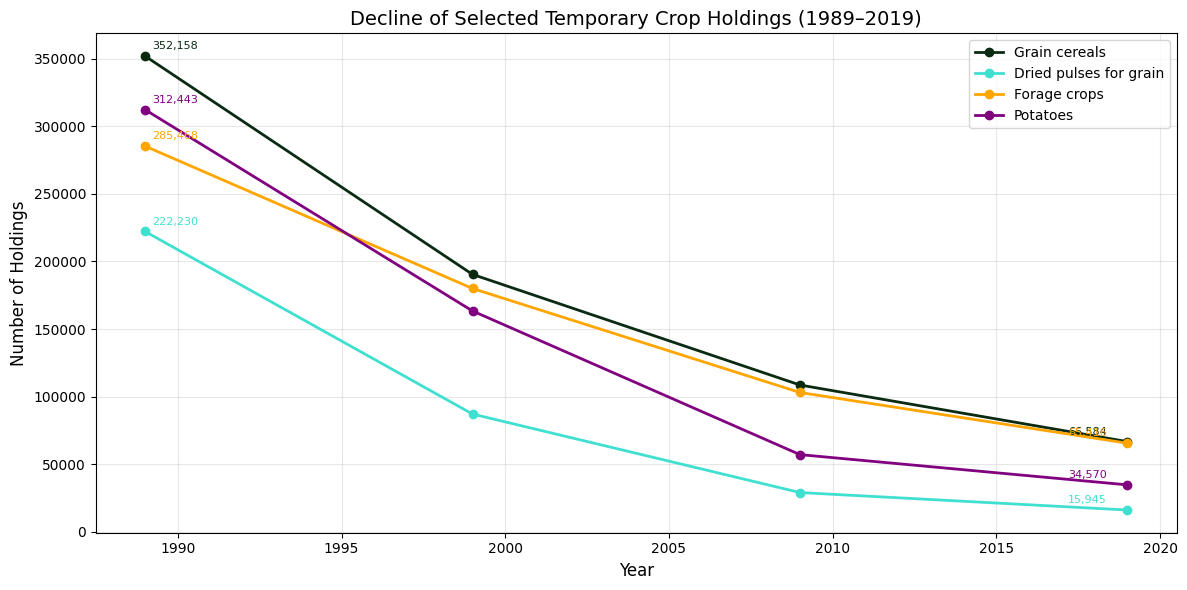

In [24]:
# ============================================
# TABLE 3.11: Temporary Crop Holdings
# ============================================

# Calculate percentage change (1989 to 2019)
temp_changes = {}
for col in temp_crop_cols:
    val_1989 = temp[col].iloc[0]
    val_2019 = temp[col].iloc[-1]
    if val_1989 != 0:
        temp_changes[col] = ((val_2019 - val_1989) / val_1989 * 100)
    else:
        # Handle cases where the starting value is zero
        temp_changes[col] = float('inf') if val_2019 > 0 else 0

# Calculate overall change for Total Temporary Crops
total_temp_1989 = temp['Total'].iloc[0]
total_temp_2019 = temp['Total'].iloc[-1]
if total_temp_1989 != 0:
    total_temp_change = ((total_temp_2019 - total_temp_1989) / total_temp_1989 * 100)
else:
    total_temp_change = float('inf') if total_temp_2019 > 0 else 0

# Create table
table_data = {'Crop Category': ['Total Temporary Crops'] + temp_crop_cols}
for year in temp['year']:
    values = [temp['Total'].iloc[temp[temp['year'] == year].index[0]]]
    for col in temp_crop_cols:
        values.append(temp[col].iloc[temp[temp['year'] == year].index[0]])
    table_data[str(year)] = values

# Add change column
# The 'Change (%)' column should have the same length as other columns (1 for 'Total' + 10 for individual crops = 11)
change_values = [f"{total_temp_change:.1f}%"] # Calculated change for 'Total Temporary Crops'
for col in temp_crop_cols:
    if isinstance(temp_changes[col], (int, float)) and not np.isinf(temp_changes[col]) and not np.isnan(temp_changes[col]):
        change_values.append(f"{temp_changes[col]:.1f}%")
    elif np.isinf(temp_changes[col]):
        change_values.append('Inf%') # Or 'N/A' or appropriate for infinite change
    else:
        change_values.append('nan%') # For NaN values

table_data['Change (%)'] = change_values

table_311 = pd.DataFrame(table_data)
print("Table 3.11 — Temporary Crop Holdings by Category (1989–2019)")
print(table_311.to_string(index=False))

# Save table as an image
fig, ax = plt.subplots(figsize=(14, len(table_311) * 0.4)) # Increased width for better text fit
ax.axis('off')
ax.axis('tight')
ax.set_title('Table 3.11 — Temporary Crop Holdings by Category (1989–2019)', loc='left', fontsize=12)

table_img = ax.table(cellText=table_311.values, colLabels=table_311.columns, loc='center', cellLoc='center')
table_img.auto_set_font_size(False)
table_img.set_fontsize(10)
table_img.auto_set_column_width(col=list(range(len(table_311.columns)))) # Automatically adjust column widths for all columns
table_img.scale(1.2, 1.2)

plt.tight_layout()
plt.savefig('table_3.11_temporary_crop_holdings.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# NEW FIGURE: Decline of Specific Temporary Crops
# ============================================

# Define the specific crops for this chart
specific_crops = ['Grain cereals', 'Dried pulses for grain', 'Forage crops', 'Potatoes']

fig, ax = plt.subplots(figsize=(12, 6))

# Using a different set of colors for clarity
colors_decline = ['#0A2A12', '#40E0D0', '#FFA500', '#800080']

for i, crop in enumerate(specific_crops):
    ax.plot(temp['year'], temp[crop], 'o-', color=colors_decline[i % len(colors_decline)], linewidth=2, markersize=6, label=crop)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Holdings', fontsize=12)
ax.set_title('Decline of Selected Temporary Crop Holdings (1989–2019)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Add value labels for 1989 and 2019 for the specific crops
for i, crop in enumerate(specific_crops):
    ax.annotate(f"{temp[crop].iloc[0]:,}",
               (temp['year'].iloc[0], temp[crop].iloc[0]),
               xytext=(5, 5), textcoords='offset points',
               fontsize=8, color=colors_decline[i % len(colors_decline)])
    ax.annotate(f"{temp[crop].iloc[-1]:,}",
               (temp['year'].iloc[-1], temp[crop].iloc[-1]),
               xytext=(-15, 5), textcoords='offset points',
               ha='right', fontsize=8, color=colors_decline[i % len(colors_decline)])

plt.tight_layout()
plt.savefig('figure_decline_selected_temporary_crops.png', dpi=300, bbox_inches='tight')
plt.show()

Table 3.12 - Permanent Crop Holdings


Table 3.12 — Permanent Crop Holdings (1989–2019)
 Year  Total Permanent Holdings Change from Previous Period Cumulative Change
 1989                    453441                           -                 -
 1999                    320484                      -29.3%            -29.3%
 2009                    225806                      -29.5%            -58.9%
 2019                    205208                       -9.1%            -68.0%


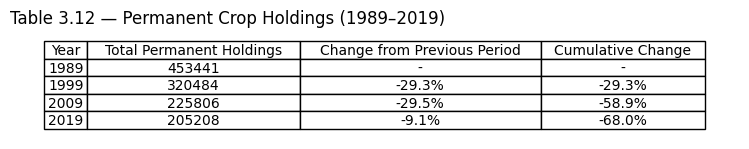

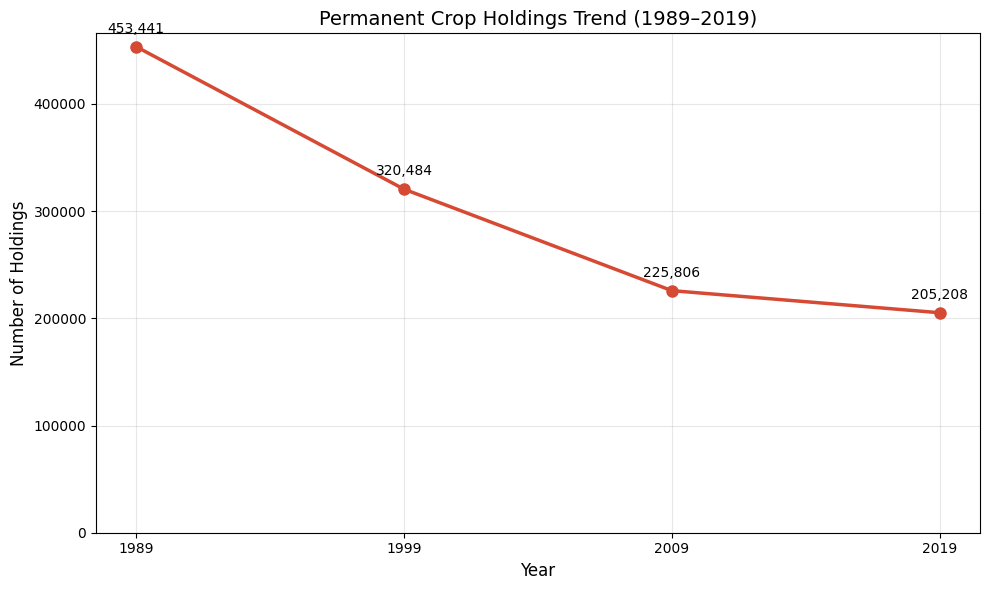

In [30]:
# ============================================
# TABLE 3.12: Permanent Crop Holdings
# ============================================

perm_change = ((perm['Total'].iloc[-1] - perm['Total'].iloc[0]) / perm['Total'].iloc[0]) * 100

perm_change_prev = []
for i in range(1, len(perm)):
    change = ((perm['Total'].iloc[i] - perm['Total'].iloc[i-1]) / perm['Total'].iloc[i-1]) * 100
    perm_change_prev.append(change)

perm_cum_change = []
cum = 0
for i, change in enumerate(perm_change_prev):
    cum += change
    perm_cum_change.append(cum)

table_312 = pd.DataFrame({
    'Year': perm['year'],
    'Total Permanent Holdings': perm['Total'],
    'Change from Previous Period': ['-'] + [f"{x:.1f}%" for x in perm_change_prev],
    'Cumulative Change': ['-'] + [f"{x:.1f}%" for x in perm_cum_change]
})

print("\nTable 3.12 — Permanent Crop Holdings (1989–2019)")
print(table_312.to_string(index=False))

# Save table as an image
fig, ax = plt.subplots(figsize=(8, len(table_312) * 0.4)) # Adjusted figure size for more columns
ax.axis('off')
ax.axis('tight')
ax.set_title('Table 3.12 — Permanent Crop Holdings (1989–2019)', loc='left', fontsize=12)

table_img = ax.table(cellText=table_312.values, colLabels=table_312.columns, loc='center', cellLoc='center')
table_img.auto_set_font_size(False)
table_img.set_fontsize(10)
table_img.auto_set_column_width(col=list(range(len(table_312.columns)))) # Automatically adjust column widths for all columns
table_img.scale(1.2, 1.2)

plt.tight_layout()
plt.savefig('table_3.12_permanent_crop_holdings.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# NEW FIGURE: Permanent Crop Holdings Trend
# ============================================

fig_trend, ax_trend = plt.subplots(figsize=(10, 6))

ax_trend.plot(perm['year'], perm['Total'], 'o-', color='#D64933', linewidth=2.5, markersize=8)

ax_trend.set_xlabel('Year', fontsize=12)
ax_trend.set_ylabel('Number of Holdings', fontsize=12)
ax_trend.set_title('Permanent Crop Holdings Trend (1989–2019)', fontsize=14)
ax_trend.grid(True, alpha=0.3)
ax_trend.set_ylim(bottom=0)
ax_trend.set_xticks(perm['year'])

# Add value labels for each point
for i, year in enumerate(perm['year']):
    ax_trend.annotate(f"{perm['Total'].iloc[i]:,}",
               (year, perm['Total'].iloc[i]),
               xytext=(0, 10), textcoords='offset points',
               ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('figure_permanent_crop_trend.png', dpi=300, bbox_inches='tight')
plt.show()

Table 3.13 - Comparative Analysis


Table 3.13 — Comparative Analysis: Temporary vs. Permanent Crops
                     Indicator    Temporary Crops    Permanent Crops
      Total change (1989–2019)             -72.1%             -54.7%
  Period of most rapid decline 1989–1999 (-37.3%) 1989–1999 (-29.3%)
     Period of slowest decline 2009–2019 (-24.4%)  2009–2019 (-9.1%)
Share of total holdings (2019)              37.8%              62.2%


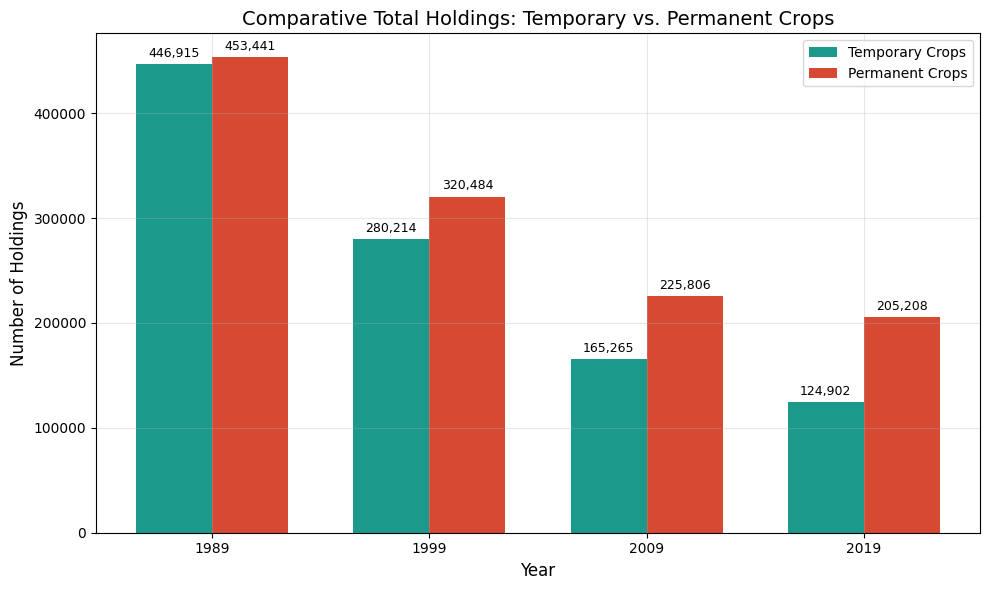

In [31]:
# ============================================
# TABLE 3.13: Comparative Analysis
# ============================================

temp_1989 = temp['Total'].iloc[0]
temp_1999 = temp['Total'].iloc[1]
temp_2009 = temp['Total'].iloc[2]
temp_2019 = temp['Total'].iloc[-1]

perm_1989 = perm['Total'].iloc[0]
perm_1999 = perm['Total'].iloc[1]
perm_2009 = perm['Total'].iloc[2]
perm_2019 = perm['Total'].iloc[-1]

table_313 = pd.DataFrame({
    'Indicator': ['Total change (1989–2019)', 'Period of most rapid decline', 'Period of slowest decline', 'Share of total holdings (2019)'],
    'Temporary Crops': [
        f"{((temp_2019 - temp_1989) / temp_1989 * 100):.1f}%",
        f"1989–1999 ({((temp_1999 - temp_1989) / temp_1989 * 100):.1f}%)",
        f"2009–2019 ({((temp_2019 - temp_2009) / temp_2009 * 100):.1f}%)",
        f"{temp_2019 / (temp_2019 + perm_2019) * 100:.1f}%"
    ],
    'Permanent Crops': [
        f"{((perm_2019 - perm_1989) / perm_1989 * 100):.1f}%",
        f"1989–1999 ({((perm_1999 - perm_1989) / perm_1989 * 100):.1f}%)",
        f"2009–2019 ({((perm_2019 - perm_2009) / perm_2009 * 100):.1f}%)",
        f"{perm_2019 / (temp_2019 + perm_2019) * 100:.1f}%"
    ]
})

print("\nTable 3.13 — Comparative Analysis: Temporary vs. Permanent Crops")
print(table_313.to_string(index=False))

# ============================================
# NEW FIGURE: Comparative Holdings Bar Chart (Histogram-like)
# ============================================

# Prepare data for the bar chart
years = temp['year'].astype(str)
temp_totals = temp['Total']
perm_totals = perm['Total']

x = np.arange(len(years))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, temp_totals, width, label='Temporary Crops', color='#1B998B')
rects2 = ax.bar(x + width/2, perm_totals, width, label='Permanent Crops', color='#D64933')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Holdings', fontsize=12)
ax.set_title('Comparative Total Holdings: Temporary vs. Permanent Crops', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on top of the bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure_comparative_total_holdings_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

Table 3.14 - Average Holding Size

In [12]:
# ============================================
# TABLE 3.14: Average Holding Size
# ============================================

avg_temp = area['Agricultural holdings area (ha)'] / temp['Total']
avg_perm = area['Agricultural holdings area (ha)'] / perm['Total']

table_314 = pd.DataFrame({
    'Year': area['year'],
    'Average Temp. Holding Size (ha)': avg_temp.round(1),
    'Average Perm. Holding Size (ha)': avg_perm.round(1)
})

print("\nTable 3.14 — Average Holding Size: Temporary vs. Permanent Crops")
print(table_314.to_string(index=False))


Table 3.14 — Average Holding Size: Temporary vs. Permanent Crops
 Year  Average Temp. Holding Size (ha)  Average Perm. Holding Size (ha)
 1989                             11.5                             11.4
 1999                             18.0                             15.7
 2009                             27.7                             20.2
 2019                             39.9                             24.3


Figure 3.13 - Major Temporary Crops

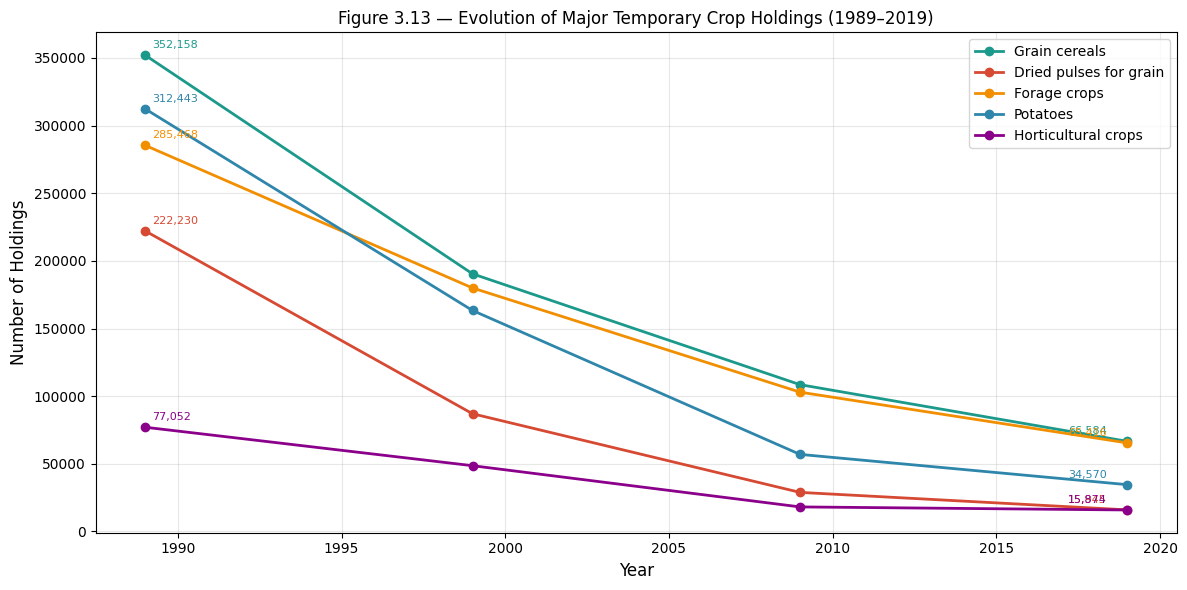

In [14]:
# ============================================
# FIGURE 3.13: Major Temporary Crops
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

major_crops = ['Grain cereals', 'Dried pulses for grain', 'Forage crops', 'Potatoes', 'Horticultural crops']
colors = ['#1B998B', '#D64933', '#F18F01', '#2E86AB', '#8B008B']

for i, crop in enumerate(major_crops):
    ax.plot(temp['year'], temp[crop], 'o-', color=colors[i], linewidth=2, markersize=6, label=crop)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Holdings', fontsize=12)
ax.set_title('Figure 3.13 — Evolution of Major Temporary Crop Holdings (1989–2019)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

# Add value labels for 1989 and 2019
for i, crop in enumerate(major_crops):
    ax.annotate(f"{temp[crop].iloc[0]:,}",
               (temp['year'].iloc[0], temp[crop].iloc[0]),
               xytext=(5, 5), textcoords='offset points',
               fontsize=8, color=colors[i])
    ax.annotate(f"{temp[crop].iloc[-1]:,}",
               (temp['year'].iloc[-1], temp[crop].iloc[-1]),
               xytext=(-15, 5), textcoords='offset points',
               ha='right', fontsize=8, color=colors[i])

plt.tight_layout()
plt.savefig('figure_3.13_major_temporary_crops.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 3.15 - Permanent Crop Holdings

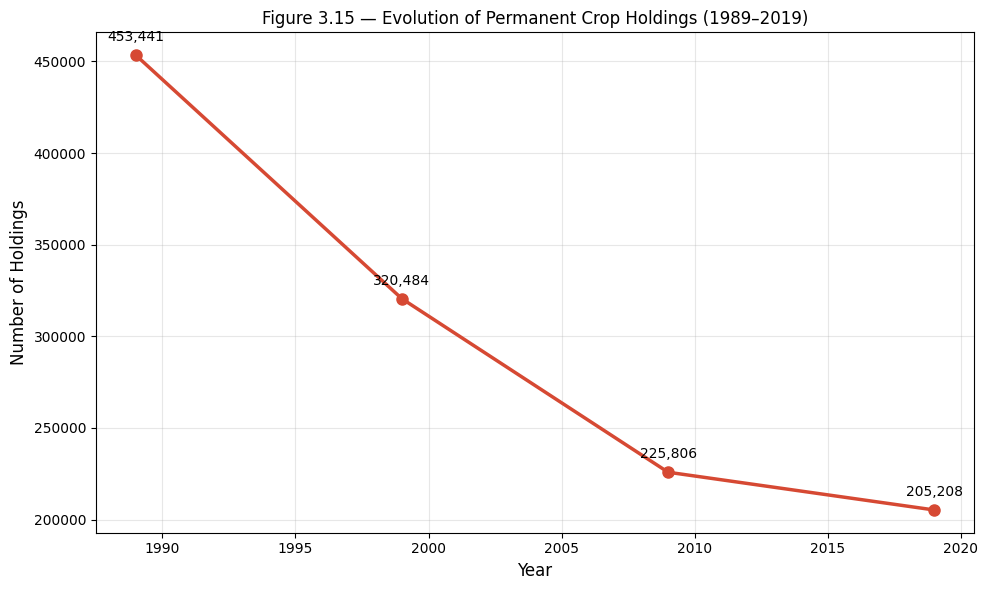

In [16]:
# ============================================
# FIGURE 3.15: Permanent Crop Holdings
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(perm['year'], perm['Total'], 'o-', color='#D64933', linewidth=2.5, markersize=8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Holdings', fontsize=12)
ax.set_title('Figure 3.15 — Evolution of Permanent Crop Holdings (1989–2019)', fontsize=12)
ax.grid(True, alpha=0.3)

# Add value labels
for i, year in enumerate(perm['year']):
    ax.annotate(f"{perm['Total'].iloc[i]:,}",
               (year, perm['Total'].iloc[i]),
               xytext=(0, 10), textcoords='offset points',
               ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('figure_3.15_permanent_crops.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 3.16 - Temporary vs Permanent

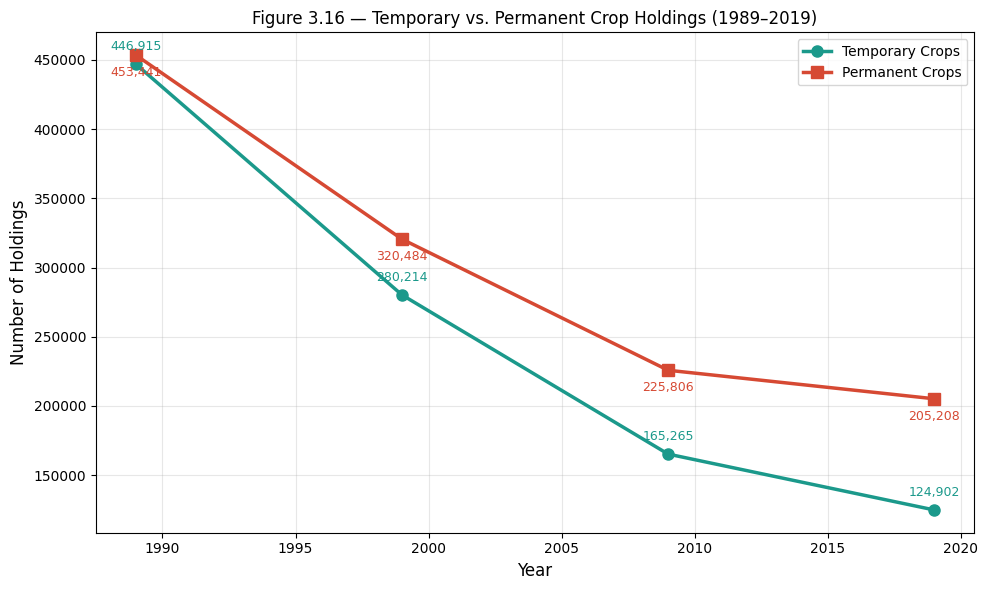

In [17]:
# ============================================
# FIGURE 3.16: Temporary vs Permanent
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(temp['year'], temp['Total'], 'o-', color='#1B998B', linewidth=2.5, markersize=8, label='Temporary Crops')
ax.plot(perm['year'], perm['Total'], 's-', color='#D64933', linewidth=2.5, markersize=8, label='Permanent Crops')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Holdings', fontsize=12)
ax.set_title('Figure 3.16 — Temporary vs. Permanent Crop Holdings (1989–2019)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

# Add value labels
for i, year in enumerate(temp['year']):
    ax.annotate(f"{temp['Total'].iloc[i]:,}",
               (year, temp['Total'].iloc[i]),
               xytext=(0, 10), textcoords='offset points',
               ha='center', fontsize=9, color='#1B998B')
    ax.annotate(f"{perm['Total'].iloc[i]:,}",
               (year, perm['Total'].iloc[i]),
               xytext=(0, -15), textcoords='offset points',
               ha='center', fontsize=9, color='#D64933')

plt.tight_layout()
plt.savefig('figure_3.16_temp_vs_perm.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 3.17 - Average Holding Size

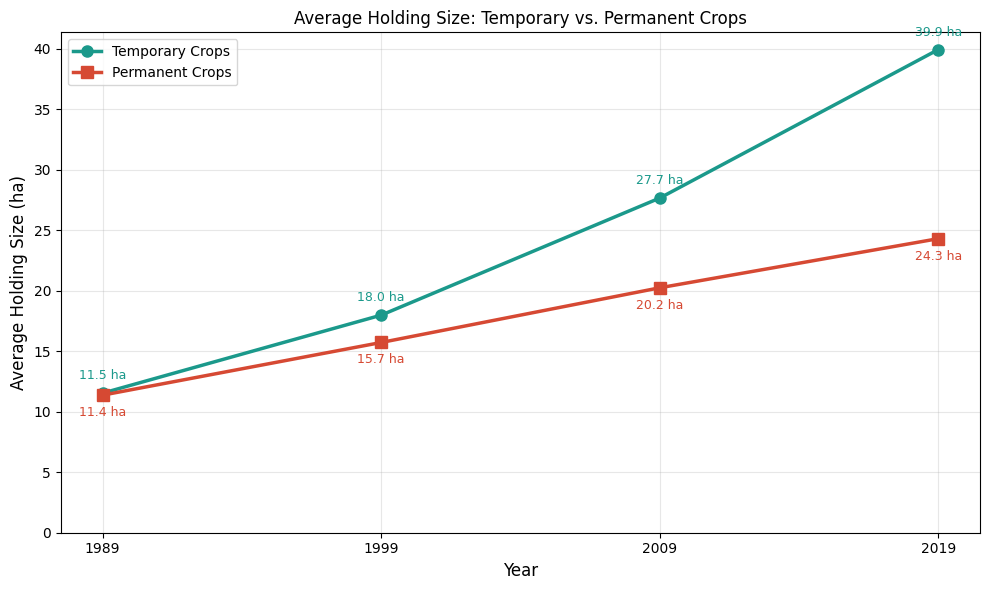

In [33]:
# ============================================
# FIGURE 3.17: Average Holding Size
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

avg_temp = area['Agricultural holdings area (ha)'] / temp['Total']
avg_perm = area['Agricultural holdings area (ha)'] / perm['Total']

ax.plot(area['year'], avg_temp, 'o-', color='#1B998B', linewidth=2.5, markersize=8, label='Temporary Crops')
ax.plot(area['year'], avg_perm, 's-', color='#D64933', linewidth=2.5, markersize=8, label='Permanent Crops')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Holding Size (ha)', fontsize=12)
ax.set_title('Average Holding Size: Temporary vs. Permanent Crops', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(bottom=0)

# Set x-axis ticks to display only the specified years
ax.set_xticks(area['year'])
ax.set_xticklabels(area['year'])

# Add value labels
for i, year in enumerate(area['year']):
    ax.annotate(f"{avg_temp.iloc[i]:.1f} ha",
               (year, avg_temp.iloc[i]),
               xytext=(0, 10), textcoords='offset points',
               ha='center', fontsize=9, color='#1B998B')
    ax.annotate(f"{avg_perm.iloc[i]:.1f} ha",
               (year, avg_perm.iloc[i]),
               xytext=(0, -15), textcoords='offset points',
               ha='center', fontsize=9, color='#D64933')

plt.tight_layout()
plt.savefig('figure_3.17_avg_holding_size.png', dpi=300, bbox_inches='tight')
plt.show()